In [28]:
import os
import pickle
import numpy as np
import pandas as pd
import neurokit2 as nk
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, filtfilt, find_peaks

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
import scipy.signal as scisig
from scipy.signal import resample

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import onnx

from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    matthews_corrcoef, roc_auc_score
)

import warnings
warnings.filterwarnings(
    "ignore",
    module="neurokit2"
)

In [ ]:
DATA_PATH = "../data/WESAD"
LABEL_WINDOW = 2
INPUT_WINDOW = 60
SAMPLE_FS = {'ACC': 32, 'BVP': 64, 'TEMP': 4, 'LABEL': 700}
USE_FREQ_HRV = False

SUBJECT_IDS = (
    [f"S{i}" for i in range(2, 12)] +
    [f"S{i}" for i in range(13, 18)]
)

def load_subject(path):
    with open(path, "rb") as f:
        return pickle.load(f, encoding="latin1")

def downsample_label(x, fs_high, fs_low):
    x = np.asarray(x[max(0, (INPUT_WINDOW-LABEL_WINDOW) * fs_high):])
    T = len(x) / fs_high
    n_out = int(round(T * fs_low))

    # time stamps for input samples
    t = np.arange(len(x)) / fs_high

    # bin edges for output samples (uniform in time)
    edges = np.linspace(0, T, n_out + 1)

    y = np.empty(n_out, dtype=int)
    for i in range(n_out):
        mask = (t >= edges[i]) & (t < edges[i+1])

        if mask.any():
            l = np.bincount(x[mask], minlength=8)[1:5].argmax()
            y[i] = l if l != 3 else 0
        else:
            # rare edge case if rounding creates an empty bin
            y[i] = y[i-1] if i > 0 else x[0]
    return y

def upsample(low_signal, high_signal, fs_high, fs_low):
    upsample_factor = fs_high / fs_low

    # Compute target length
    target_len = len(high_signal)

    # Repeat each low-frequency sample
    indices = np.floor(np.arange(target_len) / upsample_factor).astype(int)
    indices = np.clip(indices, 0, len(low_signal) - 1)

    return low_signal[indices]

def filterSignalFIR(data, cutoff=0.4, numtaps=64):
    f = cutoff / (32 / 2.0)
    FIR_coeff = scisig.firwin(numtaps, f)
    return scisig.lfilter(FIR_coeff, 1, data)

def dom_nonzero_freq(signal, fs_hz):
    """
    Returns most dominant non-zero frequency via fft
    """
    y = np.fft.fft(signal)
    yf = np.fft.fftfreq(len(signal), 1/fs_hz)
    ipart = np.argpartition(y, -2)
    f1, f2 = yf[ipart[-1]], yf[ipart[-2]] # top two dominant frequencies
    return abs(f1) if abs(f1) > 0 else abs(f2)


In [ ]:
# =========================== Data processing: Time Series data with HRV ===================================================
x = []
y = []

for sid in SUBJECT_IDS:
    print(sid)
    subject = load_subject(f"{DATA_PATH}/{sid}/{sid}.pkl")

    labels = np.array(subject['label'])
    labels = downsample_label(labels, 700, 1.0/LABEL_WINDOW)

    temp = np.array(subject['signal']['wrist']['TEMP'])

    bvp = np.array(subject['signal']['wrist']['BVP'])
    bvp_clean = nk.ppg_clean(bvp, sampling_rate=64)
    peaks, hrv_info = nk.ppg_peaks(bvp_clean, sampling_rate=64)

    acc = np.array(subject['signal']['wrist']['ACC'])
    

    for start in range(0, len(labels)):
        temp_s = temp[start * LABEL_WINDOW * 4: start * LABEL_WINDOW * 4 + INPUT_WINDOW * 4]
        bvp_s = bvp[start * LABEL_WINDOW * 64: start * LABEL_WINDOW * 64 + INPUT_WINDOW * 64]
        acc_s = acc[start * LABEL_WINDOW * 32: start * LABEL_WINDOW * 32 + INPUT_WINDOW * 32]
        label_s = labels[start]

        if np.count_nonzero(peaks[start * LABEL_WINDOW * 64: start * LABEL_WINDOW * 64 + INPUT_WINDOW * 64]) <= 5 or len(bvp_s) != INPUT_WINDOW * 64:
            continue

        hrv = []
        if USE_FREQ_HRV:
            hrv = nk.hrv(peaks[start * LABEL_WINDOW * 64: start * LABEL_WINDOW * 64 + INPUT_WINDOW * 64], sampling_rate=64, show=False)
        else:
            hrv = nk.hrv_time(peaks[start * LABEL_WINDOW * 64: start * LABEL_WINDOW * 64 + INPUT_WINDOW * 64], sampling_rate=64, show=False)
        

        data = [temp_s[:,0], bvp_s[:,0], acc_s[:,0], acc_s[:,1], acc_s[:,2], np.array(hrv["HRV_RMSSD"]), np.array(hrv["HRV_SDNN"]), np.array(hrv["HRV_pNN50"])]
        if USE_FREQ_HRV:
            data.append(np.array(hrv["HRV_LF"]))
            data.append(np.array(hrv["HRV_HF"]))
            data.append(np.array(hrv["HRV_LFHF"]))
        x_s = np.concatenate(data)

        shape_size = INPUT_WINDOW * 164 + 6 if USE_FREQ_HRV else INPUT_WINDOW * 164 + 3
        if x_s.shape[0] != shape_size:
            continue
        x.append(x_s)
        y.append(label_s)


x = np.array(x)
y = np.array(y)
print(x.shape)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2, shuffle = True, stratify=y)
    

S2


/tmp/ipykernel_1252795/372622226.py:13: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f, encoding="latin1")


3840
PPG_Peaks    63
dtype: int64
3840
PPG_Peaks    62
dtype: int64
3840
PPG_Peaks    62
dtype: int64
3840
PPG_Peaks    63
dtype: int64
3840
PPG_Peaks    62
dtype: int64
3840
PPG_Peaks    63
dtype: int64
3840
PPG_Peaks    62
dtype: int64
3840
PPG_Peaks    62
dtype: int64
3840
PPG_Peaks    62
dtype: int64
3840
PPG_Peaks    62
dtype: int64
3840
PPG_Peaks    62
dtype: int64
3840
PPG_Peaks    61
dtype: int64
3840
PPG_Peaks    62
dtype: int64
3840
PPG_Peaks    63
dtype: int64
3840
PPG_Peaks    65
dtype: int64
3840
PPG_Peaks    66
dtype: int64
3840
PPG_Peaks    68
dtype: int64
3840
PPG_Peaks    70
dtype: int64
3840
PPG_Peaks    72
dtype: int64
3840
PPG_Peaks    72
dtype: int64
3840
PPG_Peaks    73
dtype: int64
3840
PPG_Peaks    73
dtype: int64
3840
PPG_Peaks    73
dtype: int64
3840
PPG_Peaks    73
dtype: int64
3840
PPG_Peaks    74
dtype: int64
3840
PPG_Peaks    74
dtype: int64
3840
PPG_Peaks    74
dtype: int64
3840
PPG_Peaks    74
dtype: int64
3840
PPG_Peaks    73
dtype: int64
3840
PPG_Peaks

/tmp/ipykernel_1252795/372622226.py:13: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f, encoding="latin1")


3840
PPG_Peaks    74
dtype: int64
3840
PPG_Peaks    72
dtype: int64
3840
PPG_Peaks    72
dtype: int64
3840
PPG_Peaks    72
dtype: int64
3840
PPG_Peaks    72
dtype: int64
3840
PPG_Peaks    71
dtype: int64
3840
PPG_Peaks    71
dtype: int64
3840
PPG_Peaks    69
dtype: int64
3840
PPG_Peaks    69
dtype: int64
3840
PPG_Peaks    71
dtype: int64
3840
PPG_Peaks    69
dtype: int64
3840
PPG_Peaks    70
dtype: int64
3840
PPG_Peaks    69
dtype: int64
3840
PPG_Peaks    70
dtype: int64
3840
PPG_Peaks    71
dtype: int64
3840
PPG_Peaks    70
dtype: int64
3840
PPG_Peaks    70
dtype: int64
3840
PPG_Peaks    70
dtype: int64
3840
PPG_Peaks    70
dtype: int64
3840
PPG_Peaks    68
dtype: int64
3840
PPG_Peaks    67
dtype: int64
3840
PPG_Peaks    66
dtype: int64
3840
PPG_Peaks    67
dtype: int64
3840
PPG_Peaks    67
dtype: int64
3840
PPG_Peaks    67
dtype: int64
3840
PPG_Peaks    68
dtype: int64
3840
PPG_Peaks    70
dtype: int64
3840
PPG_Peaks    69
dtype: int64
3840
PPG_Peaks    70
dtype: int64
3840
PPG_Peaks

...

3840
PPG_Peaks    41
dtype: int64
3840
PPG_Peaks    41
dtype: int64
3840
PPG_Peaks    43
dtype: int64
3840
PPG_Peaks    43
dtype: int64
3840
PPG_Peaks    45
dtype: int64
3840
PPG_Peaks    46
dtype: int64
3840
PPG_Peaks    47
dtype: int64
3840
PPG_Peaks    47
dtype: int64
3840
PPG_Peaks    50
dtype: int64
3840
PPG_Peaks    50
dtype: int64
3840
PPG_Peaks    52
dtype: int64
3840
PPG_Peaks    55
dtype: int64
3840
PPG_Peaks    56
dtype: int64
3840
PPG_Peaks    56
dtype: int64
3840
PPG_Peaks    58
dtype: int64
3840
PPG_Peaks    58
dtype: int64
3840
PPG_Peaks    56
dtype: int64
3840
PPG_Peaks    56
dtype: int64
3840
PPG_Peaks    57
dtype: int64
3840
PPG_Peaks    57
dtype: int64
3840
PPG_Peaks    56
dtype: int64
3840
PPG_Peaks    56
dtype: int64
3840
PPG_Peaks    58
dtype: int64
3840
PPG_Peaks    59
dtype: int64
3840
PPG_Peaks    62
dtype: int64
3840
PPG_Peaks    63
dtype: int64
3840
PPG_Peaks    64
dtype: int64
3840
PPG_Peaks    64
dtype: int64
3840
PPG_Peaks    65
dtype: int64
3840
PPG_Peaks

/tmp/ipykernel_1252795/372622226.py:13: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f, encoding="latin1")


3840
PPG_Peaks    71
dtype: int64
3840
PPG_Peaks    71
dtype: int64
3840
PPG_Peaks    70
dtype: int64
3840
PPG_Peaks    69
dtype: int64
3840
PPG_Peaks    69
dtype: int64
3840
PPG_Peaks    67
dtype: int64
3840
PPG_Peaks    67
dtype: int64
3840
PPG_Peaks    66
dtype: int64
3840
PPG_Peaks    66
dtype: int64
3840
PPG_Peaks    66
dtype: int64
3840
PPG_Peaks    66
dtype: int64
3840
PPG_Peaks    65
dtype: int64
3840
PPG_Peaks    65
dtype: int64
3840
PPG_Peaks    65
dtype: int64
3840
PPG_Peaks    64
dtype: int64
3840
PPG_Peaks    65
dtype: int64
3840
PPG_Peaks    65
dtype: int64
3840
PPG_Peaks    66
dtype: int64
3840
PPG_Peaks    65
dtype: int64
3840
PPG_Peaks    66
dtype: int64
3840
PPG_Peaks    66
dtype: int64
3840
PPG_Peaks    66
dtype: int64
3840
PPG_Peaks    68
dtype: int64
3840
PPG_Peaks    68
dtype: int64
3840
PPG_Peaks    67
dtype: int64
3840
PPG_Peaks    67
dtype: int64
3840
PPG_Peaks    67
dtype: int64
3840
PPG_Peaks    68
dtype: int64
3840
PPG_Peaks    68
dtype: int64
3840
PPG_Peaks

/tmp/ipykernel_1252795/372622226.py:13: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f, encoding="latin1")


3840
PPG_Peaks    86
dtype: int64
3840
PPG_Peaks    87
dtype: int64
3840
PPG_Peaks    87
dtype: int64
3840
PPG_Peaks    87
dtype: int64
3840
PPG_Peaks    86
dtype: int64
3840
PPG_Peaks    87
dtype: int64
3840
PPG_Peaks    84
dtype: int64
3840
PPG_Peaks    83
dtype: int64
3840
PPG_Peaks    85
dtype: int64
3840
PPG_Peaks    85
dtype: int64
3840
PPG_Peaks    84
dtype: int64
3840
PPG_Peaks    84
dtype: int64
3840
PPG_Peaks    85
dtype: int64
3840
PPG_Peaks    85
dtype: int64
3840
PPG_Peaks    85
dtype: int64
3840
PPG_Peaks    86
dtype: int64
3840
PPG_Peaks    84
dtype: int64
3840
PPG_Peaks    84
dtype: int64
3840
PPG_Peaks    84
dtype: int64
3840
PPG_Peaks    84
dtype: int64
3840
PPG_Peaks    83
dtype: int64
3840
PPG_Peaks    83
dtype: int64
3840
PPG_Peaks    82
dtype: int64
3840
PPG_Peaks    82
dtype: int64
3840
PPG_Peaks    81
dtype: int64
3840
PPG_Peaks    81
dtype: int64
3840
PPG_Peaks    80
dtype: int64
3840
PPG_Peaks    80
dtype: int64
3840
PPG_Peaks    79
dtype: int64
3840
PPG_Peaks

In [ ]:
# =========================== Data processing: WESAD Table ===================================================
x = []
y = []

for sid in SUBJECT_IDS:
    print(sid)
    subject = load_subject(f"{DATA_PATH}/{sid}/{sid}.pkl")

    labels = np.array(subject['label'])
    labels = downsample_label(labels, SAMPLE_FS['LABEL'], 1.0/LABEL_WINDOW)

    temp = np.array(subject['signal']['wrist']['TEMP'])

    bvp = np.array(subject['signal']['wrist']['BVP'])

    acc = np.array(subject['signal']['wrist']['ACC'])
    #acc = filterSignalFIR(acc)
    

    for start in range(0, len(labels)):
        temp_s = temp[start * LABEL_WINDOW * SAMPLE_FS['TEMP']: start * LABEL_WINDOW * SAMPLE_FS['TEMP'] + INPUT_WINDOW * SAMPLE_FS['TEMP']]
        bvp_s = bvp[start * LABEL_WINDOW * SAMPLE_FS['BVP']: start * LABEL_WINDOW * SAMPLE_FS['BVP'] + INPUT_WINDOW * SAMPLE_FS['BVP']]
        acc_s = acc[start * LABEL_WINDOW * SAMPLE_FS['ACC']: start * LABEL_WINDOW * SAMPLE_FS['ACC'] + INPUT_WINDOW * SAMPLE_FS['ACC']]
        label_s = labels[start]

        acc_mean = np.mean(acc_s, axis = 1)
        acc_std = np.std(acc_s, axis = 1)
        acc_sum = acc_s.sum(axis=1)
        acc_peak_freq = [dom_nonzero_freq(acc_s[:,i], SAMPLE_FS['ACC']) for i in range(3)]
        print(f"ACC:\n{acc_mean}\n{acc_std}\n{acc_sum}\n{acc_peak_freq}")

        temp_mean = np.mean(temp_s)
        temp_std = np.std(temp_s)
        temp_min = np.min(temp_s)
        temp_max = np.max(temp_s)
        temp_range = temp_max - temp_min
        temp_slope = np.polyfit(np.arange(len(temp_s)), temp_s, 1)[0]
        print(f"TEMP:\n{temp_mean}, {temp_std}, {temp_min}, {temp_max}, {temp_range}, {temp_slope}")
        



        data = [temp_s[:,0], bvp_s[:,0], acc_s[:,0], acc_s[:,1], acc_s[:,2]]
        x_s = np.concatenate(data)

        shape_size = INPUT_WINDOW * 164 + 6 if USE_FREQ_HRV else INPUT_WINDOW * 164 + 3
        if x_s.shape[0] != shape_size:
            continue
        x.append(x_s)
        y.append(label_s)


x = np.array(x)
y = np.array(y)
print(x.shape)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2, shuffle = True, stratify=y)
    


S2


/tmp/ipykernel_1252795/1284931716.py:14: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f, encoding="latin1")


(1920, 3)
(1920, 3)


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
# ===================TEST XGB ======================================
xgb = XGBClassifier(
    n_estimators=30,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
    tree_method = 'hist',
    eval_metric=["logloss", "error"])

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
)

pred = xgb.predict(X_test)
cm = confusion_matrix(y_test, pred)
f1 = f1_score(y_test, pred)
print(f1)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Actual 0", "Actual 1"],
    yticklabels=["Predicted 0", "Predicted 1"]
)

In [26]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(x.shape[1], 1024),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 128), 
            nn.ReLU(),
            nn.Linear(128, 3)
        )

    def forward(self, x):
        return self.net(x)

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(in_channels=1, out_channels=8, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv1d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv1d(in_channels=16, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()

        self.classifier = nn.Sequential(
            nn.Flatten(),                  
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(128, 3)
        )


    def forward(self, x):
        x = self.relu(self.conv1(x.unsqueeze(dim=1)))
        print(x.shape)
        x = self.pool(x)
        print(x.shape)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.relu(self.conv3(x))
        x = self.pool(x)
        print(x.shape)

        return self.classifier(x)

tensor([0.4068, 2.8509, 5.2279], device='cuda:0', dtype=torch.float64)
Epoch [1/120] - Loss: 0.8293 - Val_Acc: 0.4651380439868975 - Val_Loss: 0.1659380662002426
Epoch [2/120] - Loss: 0.6548 - Val_Acc: 0.5243331773514273 - Val_Loss: 0.16900583779379763
Epoch [3/120] - Loss: 0.5418 - Val_Acc: 0.5389564810481984 - Val_Loss: 0.09336448903101725
Epoch [4/120] - Loss: 0.4579 - Val_Acc: 0.5411792232101076 - Val_Loss: 0.125138802255376
Epoch [5/120] - Loss: 0.3925 - Val_Acc: 0.5637576041179223 - Val_Loss: 0.09092805623008367
Epoch [6/120] - Loss: 0.3498 - Val_Acc: 0.5701918577445017 - Val_Loss: 0.0774812470521514
Epoch [7/120] - Loss: 0.3106 - Val_Acc: 0.5638745905474964 - Val_Loss: 0.07544685704356102
Epoch [8/120] - Loss: 0.2744 - Val_Acc: 0.5868039307440337 - Val_Loss: 0.06544443551252707
Epoch [9/120] - Loss: 0.2419 - Val_Acc: 0.6007253158633599 - Val_Loss: 0.0567023487289458
Epoch [10/120] - Loss: 0.2123 - Val_Acc: 0.6009592887225081 - Val_Loss: 0.043072063673475075
Epoch [11/120] - Loss:

<Axes: >

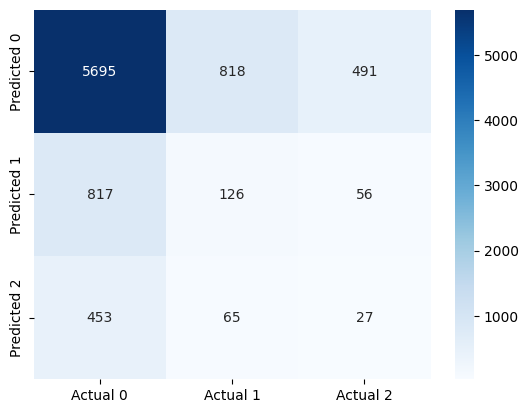

In [25]:
# ========================= TEST NN ==============================
device = "cuda:0"

model = MLP().to(torch.float64).to(device)

unique, counts = np.unique(y.copy(), return_counts=True)
class_weight = torch.tensor([len(y) / (len(unique) * counts[i]) for i in range(len(unique))]).to(torch.float64).to(device)
print(class_weight)
criterion = nn.CrossEntropyLoss(weight=class_weight)
optimizer = optim.AdamW(model.parameters(), lr=1e-4)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
train_dataset = TensorDataset(torch.tensor(X_train_scaled), torch.tensor(y_train))
test_dataset = TensorDataset(torch.tensor(X_test_scaled), torch.tensor(y_test))

dataloader_tr = DataLoader(train_dataset, batch_size=256, shuffle=True)
dataloader_te = DataLoader(test_dataset, batch_size=256, shuffle=True)


num_epochs = 120

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0

    for batch_x, batch_y in dataloader_tr:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        # Forward pass
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        if torch.isnan(batch_x).any() or torch.isinf(batch_x).any():
            print('invalid input detected')

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    model.eval()
    correct = 0
    total = 0
    val_loss_total = 0.0

    with torch.no_grad():
        for tx, ty in dataloader_te:
            tx, ty = tx.to(device), ty.to(device)

            logits = model(tx)
            preds = logits.argmax(dim=1)
            val_loss = criterion(logits, ty)
            val_loss_total += loss.item()

            correct += (preds == ty).sum().item()
            total += ty.size(0)

    val_accuracy = correct / total
    avg_loss = total_loss / len(dataloader_tr)
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f} - Val_Acc: {val_accuracy} - Val_Loss: {val_loss_total/len(dataloader_tr)}")

model.eval()
correct = 0
total = 0

y_test = []
pred = []

with torch.no_grad():
    for tx, ty in dataloader_te:
        tx, ty = tx.to(device), ty.to(device)

        logits = model(tx)
        preds = logits.argmax(dim=1)

        y_test.extend(ty.cpu())
        pred.extend(preds.cpu())

        correct += (preds == ty).sum().item()
        total += ty.size(0)

accuracy = correct / total
print(f"Test accuracy: {accuracy:.4f}")

cm = confusion_matrix(np.array(y_test), np.array(pred), labels=unique)
f1 = f1_score(np.array(y_test), np.array(pred), average='micro', labels=unique)
print(f1)
print(cm)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=[f"Actual {i}" for i in range(len(unique))],
    yticklabels=[f"Predicted {i}" for i in range(len(unique))]
)

In [ ]:
print(np.bincount(y))
print(np.bincount(y_test))

In [ ]:
device = "cuda:0"
for batch_x, batch_y in dataloader_tr:
    batch_x = batch_x.to(device)
    batch_y = batch_y.to(device)
    if torch.isnan(batch_x).any() or torch.isinf(batch_x).any():
        for ind in torch.isnan(batch_x).nonzero():
            print(batch_x[ind])

        print('invalid input detected')